# PROYECTO: REDUCCIÓN DE DIMENSIONALIDAD CON PCA

En esta lección aplicaremos de forma práctica lo aprendido acerca del Análisis de Componentes Principales (PCA) para resolver un problema de reducción de dimensionalidad.

En particular tomaremos un set de datos que contiene información asociada al precio de varios inmuebles para, después de un análisis exploratorio de los datos y de un pre-procesamiento de los mismos, usar el PCA y definir los criterios que permitirán reducir la dimensionalidad del set de datos.

Contenido:
1. [El problema a resolver](#1.-El-problema-a-resolver)
2. [El set de datos](#2.-El-set-de-datos)
3. [Análisis exploratorio](#3.-Análisis-exploratorio)
4. [Pre-procesamiento](#4.-Pre-procesamiento)
5. [Análisis de componentes principales](#5.-Análisis-de-componentes-principales)

## 1. El problema a resolver

> Hacer uso del PCA para reducir la dimensionalidad (número de columnas/variables/características/*features*) de un set de datos preservando al menos el 90% de su varianza.

## 2. El set de datos

Usaremos el set de datos [*House price: advanced regression techniques*](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) disponible en Kaggle.

En particular tomaremos únicamente el set de entrenamiento, que contiene la información de 1.460 inmuebles. Por cada inmueble se tienen datos de 79 diferentes variables (entre numéricas y categóricas) así como el precio de venta del inmueble.

Realicemos la lectura de este set de datos:

In [1]:
RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/18-2023-12-ProbabilidadNivelAvanzado/ProbabilidadNivelAvanzado-data/'

import pandas as pd
df = pd.read_csv(RUTA + 'house_prices_dataset.csv', index_col='Id')
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


Este set de datos se podría usar para construir un modelo predictivo:

$\text{datos (79 variables)} \rightarrow \text{modelo} \rightarrow \text{precio a predecir}$

Sin embargo, en este proyecto nos enfocaremos en la etapa previa a la construcción del modelo. Es decir que reduciremos la dimensionalidad del set de datos **antes** de que estos sean presentados al modelo:

$\text{datos (79 variables)} \rightarrow \text{***PCA***} \rightarrow \text{modelo} \rightarrow \text{precio a predecir}$

## 3. Análisis exploratorio

Como en todo proyecto de Machine Learning siempre debemos comenzar por entender nuestros datos llevando a cabo el Análisis Exploratorio.

Nuestro set de datos tiene 79 columnas/variables/*features*, es decir ¡un total de 79 dimensiones!. Esta alta dimensionalidad puede afectar la construcción de un modelo de Machine Learning. De allí la utilidad del PCA que nos permitirá reducir esta dimensionalidad.

Comencemos verificando cuáles columnas son de tipo numérico y cuáles de tipo categórico:

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

Hay columnas tanto categóricas (tipo "object") como numéricas (tipos "int64" y "float64").

Sin embargo, el PCA permite procesar únicamente datos de tipo numérico, así que más adelante, en la etapa de pre-procesamiento, preservaremos únicamente las columnas numéricas.

Usemos el método `describe()` para ver algunas características de estas variables numéricas:

In [3]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Vemos que en términos generales todas las variables se encuentran en diferentes rangos de valores. Tomemos nota de esta observación pues esto implica que antes de realizar el PCA tendremos que **estandarizar** los datos.

Y con esto ya hemos realizado un análisis exploratorio simple de estos datos. Vamos con el pre-procesamiento.

## 4. Pre-procesamiento

En esta fase vamos a extraer únicamente las variables numéricas y luego realizaremos la limpieza de los datos y la estandarización de los mismos.

### 4.1. Extracción de las variables numéricas

Comencemos con la extracción de las variables numéricas, que se puede realizar usando el método `select_dtypes()`:

In [4]:
df = df.select_dtypes(include='number')
df

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


Muy bien, ¡hemos pasado de 80 a 37 variables!

### 4.2. Manejo de datos faltantes

Comencemos verificando si el dataset contiene datos faltantes, usando nuevamente el método `info()`:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1460 entries, 1 to 1460
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   OverallQual    1460 non-null   int64  
 4   OverallCond    1460 non-null   int64  
 5   YearBuilt      1460 non-null   int64  
 6   YearRemodAdd   1460 non-null   int64  
 7   MasVnrArea     1452 non-null   float64
 8   BsmtFinSF1     1460 non-null   int64  
 9   BsmtFinSF2     1460 non-null   int64  
 10  BsmtUnfSF      1460 non-null   int64  
 11  TotalBsmtSF    1460 non-null   int64  
 12  1stFlrSF       1460 non-null   int64  
 13  2ndFlrSF       1460 non-null   int64  
 14  LowQualFinSF   1460 non-null   int64  
 15  GrLivArea      1460 non-null   int64  
 16  BsmtFullBath   1460 non-null   int64  
 17  BsmtHalfBath   1460 non-null   int64  
 18  FullBath

Efectivamente vemos que hay columnas con datos faltantes (no todas contienen 1.460 datos).

Podemos usar el método `isna()` para verificar específicamente cuáles son las columnas problemáticas:

In [6]:
df.isna().sum()

MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

Se trata de las columnas *LotFrontage*, *MasVnrArea* y *GarageYrBlt*.

Aunque existen maneras sofisticadas de realizar el manejo de estos datos faltantes, en este caso usaremos la más simple de todas: la eliminación.

Además de eliminar las columnas problemáticas, eliminaremos la columna *SalePrice* (que se usaría como variable a predecir si decidiéramos construir el modelo de Machine Learning).

Para esto usamos el método `drop()`:

In [8]:
df = df.drop(columns=['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'SalePrice'])
df.isna().sum()
#print(df.shape)

MSSubClass       0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
dtype: int64

Perfecto. En este punto ya tenemos un total de 1.460 observaciones (filas) y 33 variables (columnas).

### 4.3. Estandarización de los datos

El PCA es altamente dependiente de la escala de los datos. Para eliminar estos efectos de escala debemos **estandarizar** cada columna para que su promedio sea 0 y su desviación estándar sea 1.

Esto se puede implementar fácilmente con el módulo *StandardScaler* de la librería Scikit-Learn:

In [9]:
# Ejecutar esta celda en caso de que la librería no esté instalada
!pip install scikit-learn


[notice] A new release of pip available: 22.3.1 -> 23.3.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [10]:
# Estandarización

# Importar el módulo StandarScaler
from sklearn.preprocessing import StandardScaler

# Extraer los datos del DataFrame (formato NumPy)
X = df.to_numpy()

# Crear instancia del escalador
escalador = StandardScaler()

# Transformar los datos
X_s = escalador.fit_transform(X)

# Verificar
print('Promedios/desviaciones dataset original:')
print(X.mean(axis=0))
print(X.std(axis=0))

print('-'*30)
print('Promedios/desviaciones dataset estandarizado:')
print(X_s.mean(axis=0))
print(X_s.std(axis=0))

Promedios/desviaciones dataset original:
[5.68972603e+01 1.05168281e+04 6.09931507e+00 5.57534247e+00
 1.97126781e+03 1.98486575e+03 4.43639726e+02 4.65493151e+01
 5.67240411e+02 1.05742945e+03 1.16262671e+03 3.46992466e+02
 5.84452055e+00 1.51546370e+03 4.25342466e-01 5.75342466e-02
 1.56506849e+00 3.82876712e-01 2.86643836e+00 1.04657534e+00
 6.51780822e+00 6.13013699e-01 1.76712329e+00 4.72980137e+02
 9.42445205e+01 4.66602740e+01 2.19541096e+01 3.40958904e+00
 1.50609589e+01 2.75890411e+00 4.34890411e+01 6.32191781e+00
 2.00781575e+03]
[4.22860820e+01 9.97784611e+03 1.38252284e+00 1.11241818e+00
 3.01925588e+01 2.06383353e+01 4.55941866e+02 1.61264017e+02
 4.41715605e+02 4.38555057e+02 3.86455322e+02 4.36378914e+02
 4.86064268e+01 5.25300394e+02 5.18732867e-01 2.38670868e-01
 5.50727099e-01 5.02713131e-01 8.15498620e-01 2.20262727e-01
 1.62483655e+00 6.44445572e-01 7.47059036e-01 2.13731608e+02
 1.25295863e+02 6.62333334e+01 6.10982138e+01 2.93072887e+01
 5.57383170e+01 4.01635452e

Muy bien, en este punto ya hemos preparado los datos para el análisis de componentes principales.

## 5. Análisis de componentes principales


En la lección anterior vimos todos los elementos que implica la obtención de los componentes principales: cálculo de la matriz de covarianza; cálculo y ordenamiento de sus eigenvalores y eigenvectores; selección de los componentes a preservar.

Sin embargo, todo este procedimiento se reduce a **tan sólo dos líneas de código** haciendo uso del módulo *PCA* de la librería Scikit-Learn:

In [11]:
from sklearn.decomposition import PCA

# Crear instancia
pca = PCA(n_components=33) # No es necesario si quiero todos los componentes

# Cálculo de PCA sobre los datos estandarizados
pca.fit(X_s)

PCA(n_components=33)

¡Y listo, ha hemos realizado el análisis de componentes principales!

Recordemos que el PCA nos arroja los eigenvalores y eigenvectores asociados a la matriz de covarianza y organizados de manera descendente según los eigenvalores.

Estos eigenvalores se encuentran almacenados en el atributo `explained_variance_`:

In [12]:
pca.explained_variance_

array([6.40197590e+00, 3.15836409e+00, 2.14991209e+00, 1.97711623e+00,
       1.46626483e+00, 1.18384671e+00, 1.15036851e+00, 1.10843168e+00,
       1.07622128e+00, 1.04193404e+00, 1.01499089e+00, 9.94284799e-01,
       9.75997111e-01, 9.43644245e-01, 8.92406007e-01, 8.71070109e-01,
       8.37519015e-01, 8.01655806e-01, 7.66042307e-01, 7.09961233e-01,
       6.20912070e-01, 5.87454028e-01, 4.73130635e-01, 3.97245910e-01,
       3.03503806e-01, 2.81791065e-01, 2.57826356e-01, 1.94473303e-01,
       1.51982966e-01, 1.32569054e-01, 9.97221545e-02, 1.26256713e-30,
       1.40702874e-31])

En primer lugar vemos que tenemos exactamente 33 componentes (que fue la cantidad que definimos que queríamos calcular):

In [13]:
pca.explained_variance_.shape

(33,)

Y además podemos ver que están organizados de manera descendente.

Asociado a cada uno de estos componentes tendremos los correspondientes eigenvectores, que se encuentran almacenados en el atributo `components_`:

In [14]:
pca.components_

array([[-1.14470890e-02,  1.17161833e-01,  3.17527154e-01, ...,
        -1.01376087e-02,  2.64661552e-02, -1.64009644e-02],
       [ 1.85847758e-01, -6.69479137e-02, -2.89506967e-02, ...,
         2.39177584e-02,  2.56239303e-02, -3.46418765e-02],
       [-7.46237146e-02,  2.83985578e-01, -1.43179116e-01, ...,
         6.68485664e-02, -2.24068357e-02,  1.11991334e-02],
       ...,
       [-2.97535496e-02, -4.81337717e-03, -6.63927704e-02, ...,
         1.10464251e-02, -5.66665985e-03,  9.49434779e-03],
       [ 4.18811098e-16,  3.60487134e-17,  3.29673058e-16, ...,
        -2.26747708e-17,  2.16372583e-16,  1.64087173e-16],
       [-0.00000000e+00,  2.15101068e-16, -4.96496131e-16, ...,
        -4.85798510e-17, -4.81617637e-17, -5.58076474e-17]])

Este atributo es un arreglo de NumPy de tamaño 33 x 33:

In [15]:
pca.components_.shape

(33, 33)

El número de filas (33) se debe a que le hemos indicado al módulo `PCA` que calculara 33 componentes, mientras que el número de columnas (33) se debe a que el dataset original tiene una dimensionalidad igual a 33.

Por ejemplo, si recalculamos el PCA pero ahora definimos sólo 4 componentes, el arreglo `components_` tendrá un tamaño de 4x33:

In [16]:
pca = PCA(n_components=4)
pca.fit(X_s)
pca.components_.shape
#pca.explained_variance_

(4, 33)

Volvamos al análisis original (`n_components=33`) pues nos interesa analizar la totalidad de los componentes principales que se pueden calcular:

In [17]:
pca = PCA(n_components=33)
pca.fit(X_s)
pca.components_.shape

(33, 33)

### 5.1. La varianza explicada

Recordemos que un concepto importante en el PCA es la **varianza explicada**: la contribución de cada componente (eigenvalor) a la varianza total del set de datos.

Esta varianza explicada es simplemente el porcentaje de cada eigenvalor con respecto a la suma total de eigenvalores:

$\text{varianza_explicada}_i = \frac{\lambda_i}{\sum_j \lambda_j}x100\%$

El módulo PCA automáticamente calcula estas varianzas explicadas. El resultado se encuentra almacenado en el atributo `explained_variance_ratios_`:

In [18]:
pca.explained_variance_ratio_

array([1.93866393e-01, 9.56424494e-02, 6.51042288e-02, 5.98715770e-02,
       4.44018346e-02, 3.58495713e-02, 3.48357753e-02, 3.35658326e-02,
       3.25904285e-02, 3.15521328e-02, 3.07362332e-02, 3.01092055e-02,
       2.95554127e-02, 2.85756944e-02, 2.70240839e-02, 2.63779844e-02,
       2.53619810e-02, 2.42759614e-02, 2.31975037e-02, 2.14992411e-02,
       1.88026299e-02, 1.77894443e-02, 1.43274719e-02, 1.20295098e-02,
       9.19078564e-03, 8.53327446e-03, 7.80756857e-03, 5.88909399e-03,
       4.60238994e-03, 4.01449253e-03, 3.01981369e-03, 3.82334047e-32,
       4.26080310e-33])

Vemos que estas contribuciones ya se encuentran organizadas de manera descendente. Por ejemplo, el primer componente principal ($PC_1$) tiene una varianza explicada de 1.93e-01 es decir que contiene el 19.3% de la varianza del set de datos original, mientras que el último componente principal ($PC_{33}$) tiene una varianza explicada de 4.26e-33 es decir prácticamente el 0% de la varianza del set original.

Podemos generar una gráfica para visualizar de manera simultánea la varianza explicada de cada uno de los 33 componentes principales:

In [19]:
# Almacenemos los nombres de cada componente (PC_1 a PC_33) y las varianzas explicadas en un DataFrame de Pandas

# Extraer los nombres de los componentes
comp_names = [f'PC_{i+1}' for i in range(pca.components_.shape[0])]

# Extraer las varianzas explicadas
ratios = pca.explained_variance_ratio_

# Crear el dataframe
df_pca = pd.DataFrame(data={'Componente':comp_names, '% varianza':100*ratios})
df_pca

,Componente,% varianza
0,PC_1,1.938664e+01
1,PC_2,9.564245e+00
2,PC_3,6.510423e+00
3,PC_4,5.987158e+00
4,PC_5,4.440183e+00
5,PC_6,3.584957e+00
6,PC_7,3.483578e+00
7,PC_8,3.356583e+00
8,PC_9,3.259043e+00
9,PC_10,3.155213e+00


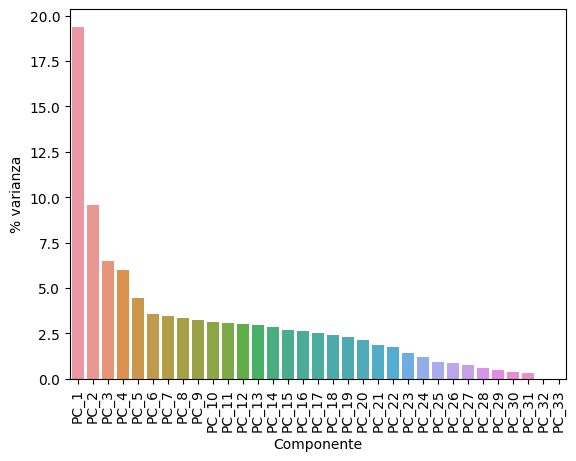

In [20]:
# Y ahora sí grafiquemos las varianzas explicadas
import seaborn as sns

ax = sns.barplot(data=df_pca, x='Componente', y='% varianza')
ax.tick_params(axis='x', rotation=90)

Además, si sumamos todas las contribuciones debemos tener un valor exactamente igual a 1 (o el 100% de la varianza del set de datos original):

In [21]:
pca.explained_variance_ratio_.sum()

1.0000000000000002

### 5.2. Reducción de dimensionalidad

La reducción de dimensionalidad consiste en tomar los primeros *k* componentes tal que preservemos el *X*% de la varianza explicada.

En el caso particular del proyecto lo que buscamos es:

> Hacer uso del PCA para reducir la dimensionalidad (número de variables/características/*features*) de un set de datos preservando al menos el 90% de su varianza.

Así que nos interesa determinar cuántos componentes equivalen al menos al 90% de la varianza.

Para hacer esto resulta útil crear una nueva columna en el *DataFrame* con la información de la varianza acumulada:

In [23]:
# Agregar columna "varianza_acumulada"
df_pca['varianza_acumulada_%'] = df_pca['% varianza'].cumsum()
df_pca

,Componente,% varianza,varianza_acumulada_%
0,PC_1,1.938664e+01,19.386639
1,PC_2,9.564245e+00,28.950884
2,PC_3,6.510423e+00,35.461307
3,PC_4,5.987158e+00,41.448465
4,PC_5,4.440183e+00,45.888648
5,PC_6,3.584957e+00,49.473605
6,PC_7,3.483578e+00,52.957183
7,PC_8,3.356583e+00,56.313766
8,PC_9,3.259043e+00,59.572809
9,PC_10,3.155213e+00,62.728022


En el *DataFrame* anterior resulta sencillo ver el número de componentes que, sumados, totalizan una varianza explicada de al menos el 90%. Esto corresponde a los componentes del 1 al 21.

Pero este cálculo lo podemos hacer de forma automática con unas pocas líneas de código:

In [24]:
# Determinar el número de componentes que representan el X% de la varianza acumulada
import numpy as np

umbral = 90
num_components = np.argmax(df_pca['varianza_acumulada_%'] >= umbral) + 1
num_components

21

Y con esto ya podemos ahora sí llevar a cabo la reducción de dimensionalidad.

Primero calculamos la PCA con el número de componentes que acabamos de calcular:

In [25]:
# Crear instancia de "PCA" con los componentes deseados
pca = PCA(n_components=num_components)

# Realizar el cálculo de la PCA sobre el dataset original estandarizado (arreglo de 1.460x33)
pca.fit(X_s)

PCA(n_components=21)

Y ahora reducimos las dimensiones del dataset original para que ahora tenga 21 variables (columnas) en lugar de las 33 originales. Para esto usamos el método `transform()`:

In [26]:
# Proyectar el dataset original (espacio de 33 dimensiones) al nuevo espacio de 21 dimensiones
X_pca = pca.transform(X_s)

# Y verifiquemos los tamaños originales y resultante
print(f'Tamaño dataset antes de PCA: {X_s.shape}')
print(f'Tamaño dataset después de PCA (componentes que explican el {umbral}% de la varianza): {X_pca.shape}')

Tamaño dataset antes de PCA: (1460, 33)
Tamaño dataset después de PCA (componentes que explican el 90% de la varianza): (1460, 21)


¡Y en este punto ya hemos usado el PCA para reducir la dimensionalidad del dataset!

El dataset resultante contiene 21 componentes (PC_1 a PC_21) que explican el 90% de la varianza del dataset original. Así que podemos decir que el dataset resultante contiene el 90% de la información presente en el dataset original.

Además, es importante resaltar que tras el PCA no es posible interpretar las variables en términos de las características originales. Es decir, cada componente PC_i tiene contribuciones en diferente proporción de cada columna (variable) del dataset original. Esto es precisamente una limitación del PCA.